In [90]:
import warnings
warnings.filterwarnings("ignore")

In [210]:
import os
import string

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import (
    get_project_path
)

from flonacomldft.utils.plots import (
    load_ag6_image
)

In [211]:
path_save_figures = get_project_path() + '/figures/preprint_v2/plots'

In [212]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.1,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. MLP', 'MD', 'ab-flowMC',  
                          'Pretrained ab-flowMC', 
                        'ab-flowMM w.o. MLP', 'ab-flowMM', 'MCMC w. flow from MD'],
                        ['#0077BB', '#cdb332',  '#CC3311',  
                        '#000000',
                        '#0077BB', '#CC3311', '#cdb332']
                        ))

sns.color_palette(methods_color.values())

[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.8, 0.2, 0.06666666666666667),
 (0.0, 0.0, 0.0),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902)]

In [213]:
np.random.seed(42)

In [214]:
methods = ['adaptive', 'mixture_model']

simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

# 1. Circular dichroism

In [215]:
path_opt_spc_dft = get_project_path() + '/8-optical-spectra'

## 1.a Free minima energy isomers 0K

In [218]:
data0K_is0 = np.loadtxt(path_opt_spc_dft +'/minima_is0/spectrum_with_05.50eV.dat', skiprows=1)
data0K_is1 = np.loadtxt(path_opt_spc_dft +'/minima_is1/spectrum_with_05.50eV.dat', skiprows=1)

## 1.b Molecular dynamics 350K

In [219]:
path_opt_spc_md = get_project_path() + '/8-optical-spectra/MD/'

n=48

data350K_is0_md = [np.loadtxt(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                               skiprows=1) for i in range(49) if os.path.isfile(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]
data350K_is1_md = [np.loadtxt(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                                 skiprows=1) for i in range(50) if os.path.isfile(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]

Ydata350K_is0_md = np.array([data350K_is0_md[i][:,2] for i in range(len(data350K_is0_md))])
Ydata350K_is1_md = np.array([data350K_is1_md[i][:,2] for i in range(len(data350K_is1_md))])

mean_is0_md = np.mean(Ydata350K_is0_md, axis=0)
std_is0_md = np.std(Ydata350K_is0_md, axis=0)/np.sqrt(Ydata350K_is0_md.shape[0])

mean_is1_md = np.mean(Ydata350K_is1_md, axis=0)
std_is1_md = np.std(Ydata350K_is1_md, axis=0)/np.sqrt(Ydata350K_is1_md.shape[0])

len(data350K_is0_md), len(data350K_is1_md)

(48, 48)

## 1.c AbflowMC 350K

In [220]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        #0: 31959918,
                        #1: 319599111
                        #0: 31959917,
                        #1: 319599110,
                        #0: 31959916,
                        #1: 31959919,
                        #0: 32504326,
                        #1: 32510291,
                        0: 32606140,
                        1: 32606143
                    },

                    simulation_types[methods[0]][1]: {
                        0: 31961552,
                        1: 31961553
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]:
                        33041081,
                        #32948391,
                        #32901861, paper 
                        #32760171, best 
                        #32094541,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [221]:
path_opt_spc_mlp = get_project_path() + '/9-optical-spectra-mlp'

data350K_is0_mlp = [np.loadtxt(path_opt_spc_mlp +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][0], i),
                               skiprows=1) for i in range(n) ]
data350K_is1_mlp = [np.loadtxt(path_opt_spc_mlp +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][1], i),
                                 skiprows=1) for i in range(n) ]

Ydata350K_is0_mlp = np.array([data350K_is0_mlp[i][:,2] for i in range(len(data350K_is0_mlp))])
Ydata350K_is1_mlp = np.array([data350K_is1_mlp[i][:,2] for i in range(len(data350K_is1_mlp))])

mean_is0_mlp = np.mean(Ydata350K_is0_mlp, axis=0)
std_is0_mlp = np.std(Ydata350K_is0_mlp, axis=0)/np.sqrt(Ydata350K_is0_mlp.shape[0])

mean_is1_mlp = np.mean(Ydata350K_is1_mlp, axis=0)
std_is1_mlp = np.std(Ydata350K_is1_mlp, axis=0)/np.sqrt(Ydata350K_is1_mlp.shape[0])

## 1.d AbflowMC w.o. MLP 350K

In [222]:
data350K_is0_dft = [np.loadtxt(path_opt_spc_dft +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][0], i), 
                           skiprows=1) for i in range(n)]

data350K_is1_dft = [np.loadtxt(path_opt_spc_dft +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][1], i),
                            skiprows=1) for i in range(n)]

Ydata350K_is0_dft = np.array([data350K_is0_dft[i][:,2] for i in range(n)])
Ydata350K_is1_dft = np.array([data350K_is1_dft[i][:,2] for i in range(n)])

mean_is0_dft = np.mean(Ydata350K_is0_dft, axis=0)
std_is0_dft = np.std(Ydata350K_is0_dft, axis=0)/np.sqrt(Ydata350K_is0_dft.shape[0])


mean_is1_dft = np.mean(Ydata350K_is1_dft, axis=0)
std_is1_dft = np.std(Ydata350K_is1_dft, axis=0)/np.sqrt(Ydata350K_is1_dft.shape[0])


# 2. Final data

In [223]:
data_circ_dichroism = { 'energy': data0K_is0[:,0],
                        'T0K_is0_dft': data0K_is0[:,2],
                        'T0K_is1_dft': data0K_is1[:,2],
                        'mean_350K_is0_mlp': mean_is0_mlp, 
                        'mean_350K_is1_mlp': mean_is1_mlp,
                        'std_350K_is0_mlp': std_is0_mlp,
                        'std_350K_is1_mlp': std_is1_mlp,
                        'mean_350K_is0_dft': mean_is0_dft, 
                        'mean_350K_is1_dft': mean_is1_dft,
                        'std_350K_is0_dft': std_is0_dft,
                        'std_350K_is1_dft': std_is1_dft,
                        'mean_350K_is0_md': mean_is0_md, 
                        'mean_350K_is1_md': mean_is1_md,
                        'std_350K_is0_md': std_is0_md,
                        'std_350K_is1_md': std_is1_md,
        }

In [224]:
opt_spc_colors = dict(zip(['T=OK', 'MD', 'ab-flowMC', 'ab-flowMC w.o. MLP'],
                        ['#808080', '#cdb332', '#CC3311', 
                        '#0077BB']))

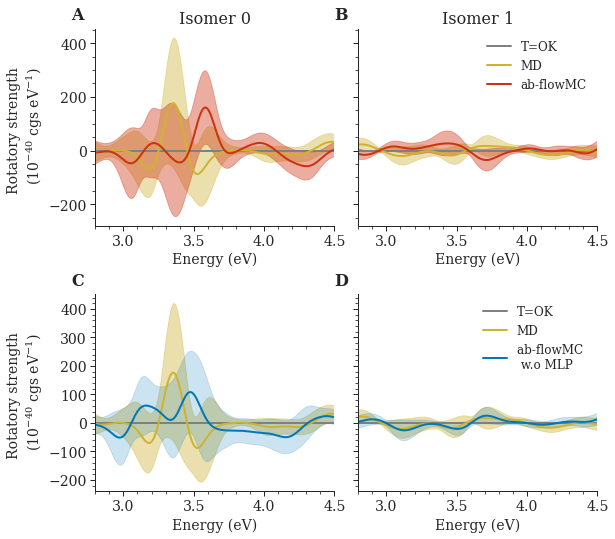

In [238]:
figsize=(4.5*2, 4.25*2)
fontsize=16
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.35
wspace=0.1

ncols = 2
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0][0]
ax2 = axs[0][1]
ax3 = axs[1][0]
ax4 = axs[1][1]

# -- item to subplot and delete top and right axis lines --

posx = -0.1
posy = 1.05

for n, ax in enumerate([ax1, ax2, ax3, ax4]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

from scipy.stats import t

conf_inter = lambda perc, n: t.ppf(1-perc/2, n-1)

for i, ax in enumerate([ax1, ax2]):
    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    ax.fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] - conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] + conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)
    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['ab-flowMC'],
            label='ab-flowMC'
            )
    
    ax.fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] - conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] + conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
        color=opt_spc_colors['ab-flowMC'], alpha=0.4)

    ax.set_title('Isomer {:d}'.format(i))


for i, ax in enumerate([ax3, ax4]) :

    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )
    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    ax.fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] - conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] + conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=ax,
            color=opt_spc_colors['ab-flowMC w.o. MLP'],
            label='ab-flowMC \n w.o MLP'
            )
    
    ax.fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] - conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] + conf_inter(0.05, 48)*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
        color=opt_spc_colors['ab-flowMC w.o. MLP'], alpha=0.2)
    
    #ax.set_title('Isomer {:d}'.format(i))

# -- set the limits of x and y axis --

for ax in [ax1, ax2, ax3, ax4]:

    ax.set_xlabel('Energy (eV)')
    ax.set_xlim(2.8, 4.5)

ax1.set_ylabel('Rotatory strength \n (10$^{-40}$ cgs eV$^{-1}$)')

ax1.sharey(ax2)
ax1.legend().remove()
ax2.legend(loc='best', frameon=False)

ax3.set_ylabel('Rotatory strength \n (10$^{-40}$ cgs eV$^{-1}$)')

ax4.sharey(ax3)
ax3.legend().remove()
ax4.legend(loc='best', frameon=False)

### -- sharing axis subplots --


plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)

plt.savefig(path_save_figures+'/figure_circular_dichroism.pdf',
            dpi=300, 
            facecolor='white',
            transparent=False)

# Collective variables

In [226]:
from ase.io import read
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

In [227]:
coord_maps = Coordinates_mapping()

In [228]:
isomers_0_mlp = [read(path_opt_spc_mlp +'/is0_{:d}/sample_{:d}/gs.out'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][0], i)
                                    ) for i in range(48) ]

isomers_1_mlp = [read(path_opt_spc_mlp +'/is1_{:d}/sample_{:d}/gs.out'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][1], i)
                                    ) for i in range(48) ]

cvs_0_mlp = coord_maps.get_collective_variables_from_trajectory(isomers_0_mlp)
cvs_1_mlp = coord_maps.get_collective_variables_from_trajectory(isomers_1_mlp)

In [229]:
isomers_0_dft = [read(path_opt_spc_dft +'/is0_{:d}/sample_{:d}/gs.out'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][0], i)
                                    ) for i in range(48) ]

isomers_1_dft = [read(path_opt_spc_dft +'/is1_{:d}/sample_{:d}/gs.out'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][1], i)
                                    ) for i in range(48) ]

cvs_0_dft = coord_maps.get_collective_variables_from_trajectory(isomers_0_dft)
cvs_1_dft = coord_maps.get_collective_variables_from_trajectory(isomers_1_dft)

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [231]:
CVS = []

for i, cvs_set in enumerate([cvs_0_dft, cvs_1_dft]):
    cvs = pd.DataFrame(cvs_set, columns=['R', 'C'])
    cvs['Method'] = 'ab-flowMC w.o. MLP'
    cvs['Isomer'] = i
    CVS.append(cvs)

for i, cvs_set in enumerate([cvs_0_mlp, cvs_1_mlp]):
    cvs = pd.DataFrame(cvs_set, columns=['R', 'C'])
    cvs['Method'] = 'ab-flowMC'
    cvs['Isomer'] = i
    CVS.append(cvs)

CVS = pd.concat(CVS)
CVS

,R,C,Method,Isomer
0,10.244945,2.467200,ab-flowMC w.o. MLP,0
1,10.125306,2.388358,ab-flowMC w.o. MLP,0
2,10.060391,2.431262,ab-flowMC w.o. MLP,0
3,9.931964,2.465546,ab-flowMC w.o. MLP,0
4,10.388233,2.428152,ab-flowMC w.o. MLP,0
...,...,...,...,...
43,10.738375,2.205206,ab-flowMC,1
44,10.345465,2.228183,ab-flowMC,1
45,10.627797,2.237615,ab-flowMC,1
46,10.357782,2.218115,ab-flowMC,1


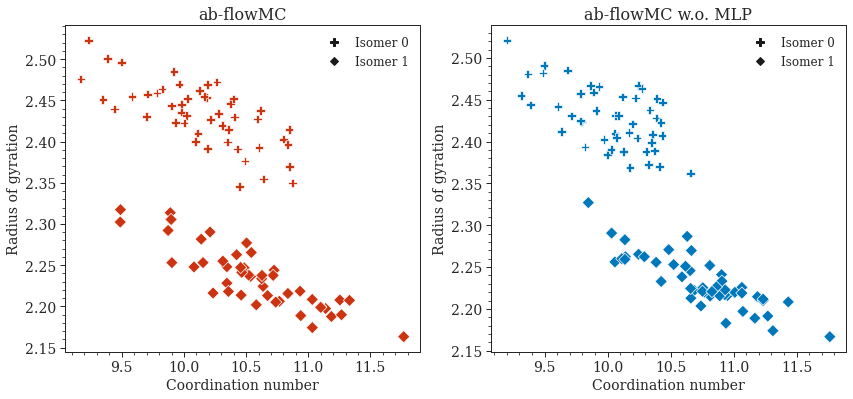

In [249]:
import matplotlib.lines as mlines

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# -- plot cvs (samples) -- 
for method, ax in zip(["ab-flowMC", "ab-flowMC w.o. MLP"], axs):

    sns.scatterplot(
        data=CVS[CVS['Method'] == method],
        x='R', 
        y='C', 
        hue='Method',
        style='Isomer',
        ax=ax,
        palette=methods_color,
        s=markersize*15,
        markers=['P', 'D'],
        alpha=1,
        legend=False,
    )

    ax.set_xlabel('Coordination number')
    ax.set_ylabel('Radius of gyration')

    ax.set_title(method)

    plus = mlines.Line2D([], [], color='k', marker='P', linestyle='None',
                          markersize=8, label='Isomer 0')
    diamond = mlines.Line2D([], [], color='k', marker='D', linestyle='None',
                              markersize=6, label='Isomer 1')
    

    ax.legend(handles=[plus, diamond])

plt.savefig(path_save_figures+'/figure_cv_opt_spectrum_samples.pdf',
            dpi=300, 
            facecolor='white',
            transparent=False)
